## **Ejercicio 1**

In [1]:
import pandas as pd
df = pd.read_csv('info_customers.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.isna().sum()

### Analisis Exploratorio


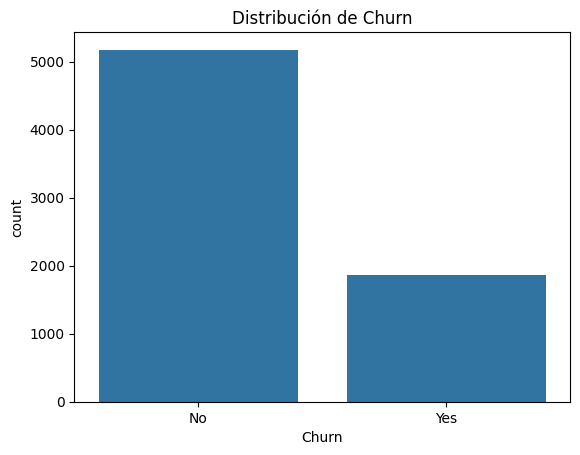

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='Churn') # Importante para ver el desbalance de clases
plt.title("Distribución de Churn") 
plt.show()

In [ ]:
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure según Churn")
plt.show()

In [ ]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.xticks(rotation=45)
plt.title("Churn según tipo de contrato")
plt.show()

In [ ]:
# Histograma
sns.histplot(x = "MonthlyCharges", hue = "Churn", data = df)

plt.show()

### Algunas columnas no son reconocidas como numericas


In [ ]:
# Veo el tipo de dato
df.dtypes

In [ ]:
df.nunique()

In [ ]:
for col in df.columns:
    if col != 'customerID':
        print(f"\nColumna: {col}")
        print(df[col].value_counts())

In [3]:
df = pd.get_dummies(df, columns=["gender", "Partner", "Dependents", "Contract", "Churn", "PaymentMethod", "PaperlessBilling", "StreamingMovies", "StreamingTV", "TechSupport", "DeviceProtection", "OnlineBackup", "OnlineSecurity", "InternetService", "MultipleLines", "PhoneService"])
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

*Borro Las columnas customerID y Churn_No, ya que no tiene sentido usarlas. customerID solo identifica al cliente y mi variable target tiene mas sentido que sea Churn_Yes*

In [4]:
df = df.drop(columns=["customerID"])
df = df.drop(columns=["Churn_No"])

*Ahora todas las columnas son numericas.*

In [ ]:
df.dtypes

 ## **Ejercicio 2**

*Antes de resolver el problema de los valores nulos, tengo que separar la muestra.*
*Si no, estaria haciendo Data Leakage. Porque estaria usando informacion del test para el training.*

## **Valores Faltantes**

*Se reemplazan los valores faltantes por la media para mantener un valor representativo sin alterar significativamente la distribución de los datos.*

In [5]:
# Separo Training y Test
from sklearn.model_selection import train_test_split

X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

# Training (80%), Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
imputer.fit(X_train)
X_train = imputer.transform(X_train)
X_test = imputer.transform(X_test)

## **Escalado**

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## **Cross-Validation con K-Fold (K=5)**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# K-FOLD
kf = KFold(n_splits=5, shuffle=True, random_state=42)

#Metricas
accuracies = []
precisions = []
recalls = []
f1s = []

matrices = []

X_train_df = pd.DataFrame(X_train)
for train_index, val_index in kf.split(X_train):
    
    #Modelo
    X_train_fold = X_train_df.iloc[train_index].copy()
    X_val_fold = X_train_df.iloc[val_index].copy()
    y_train_fold = y.iloc[train_index]
    y_val_fold = y.iloc[val_index]

    
    modelo = KNeighborsClassifier(n_neighbors=10)
    modelo.fit(X_train_fold, y_train_fold)

    
    y_pred = modelo.predict(X_val_fold)

    #CODIGO PARA METRICAS Y MATRICES
    acc = accuracy_score(y_val_fold, y_pred)
    prec = precision_score(y_val_fold, y_pred)
    rec = recall_score(y_val_fold, y_pred)
    f1 = f1_score(y_val_fold, y_pred)
        
        
    matrices.append(confusion_matrix(y_val_fold, y_pred))

    # guardar
    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)


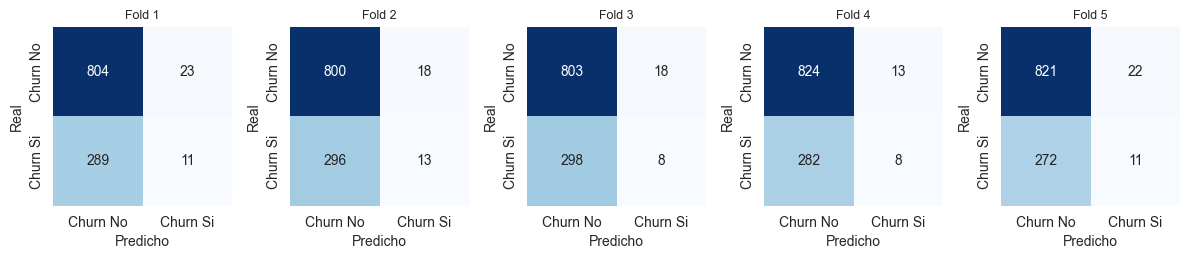

Accuracy promedio: 0.7282588995131607
Precision promedio: 0.35297245449048104
Recall promedio: 0.034267423954884975
F1-score promedio: 0.06231976425897258


In [ ]:
#Ploteo las matrices de confusión

sns.set_style("white")

fig, axes = plt.subplots(1, 5, figsize=(12, 2.5)) 

for i, ax in enumerate(axes):
    
    sns.heatmap(
        matrices[i],
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        ax=ax,
        xticklabels=["Churn No", "Churn Si"],
        yticklabels=["Churn No", "Churn Si"]
    )
    
    ax.set_title(f"Fold {i+1}", fontsize=9)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()


# resultados finales
print("Accuracy promedio:", np.mean(accuracies))
print("Precision promedio:", np.mean(precisions))
print("Recall promedio:", np.mean(recalls))
print("F1-score promedio:", np.mean(f1s))

## **Evaluando el modelo sobre todo el training set**

In [20]:
modelo = KNeighborsClassifier(n_neighbors=10)

modelo.fit(X_train, y_train)

# predicción
y_pred = modelo.predict(X_test)

# métricas
accuracy_Test = accuracy_score(y_test, y_pred)
precision_Test = precision_score(y_test, y_pred)
recall_Test = recall_score(y_test, y_pred)
f1s_Test = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)



Accuracy promedio: 0.7686302342086586
Precision promedio: 0.5827586206896552
Recall promedio: 0.45187165775401067
F1-score promedio: 0.5090361445783133


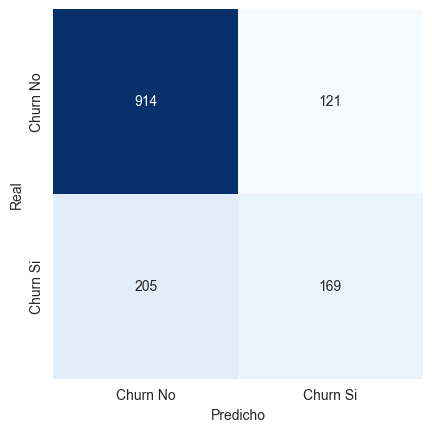

In [ ]:
sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        xticklabels=["Churn No", "Churn Si"],
        yticklabels=["Churn No", "Churn Si"]
    )

plt.xlabel("Predicho")
plt.ylabel("Real")

# resultados finales
print("Accuracy promedio:", accuracy_Test)
print("Precision promedio:", precision_Test)
print("Recall promedio:", recall_Test)
print("F1-score promedio:", f1s_Test)

## Balanceando el dataset con Oversampling

In [22]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

rus = RandomOverSampler(random_state=42)

X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

print("Distribución original:", Counter(y_train))
print("Distribución balanceada:", Counter(y_train_res))

Distribución original: Counter({False: 4139, True: 1495})
Distribución balanceada: Counter({False: 4139, True: 4139})


In [24]:
#Entrenar con los datos balanceados

from sklearn.metrics import classification_report, confusion_matrix

model_bal = KNeighborsClassifier(n_neighbors=10)

model_bal.fit(X_train_res, y_train_res)


y_pred_bal = model_bal.predict(X_test)



              precision    recall  f1-score   support

       False       0.88      0.72      0.79      1035
        True       0.49      0.74      0.59       374

    accuracy                           0.72      1409
   macro avg       0.69      0.73      0.69      1409
weighted avg       0.78      0.72      0.74      1409



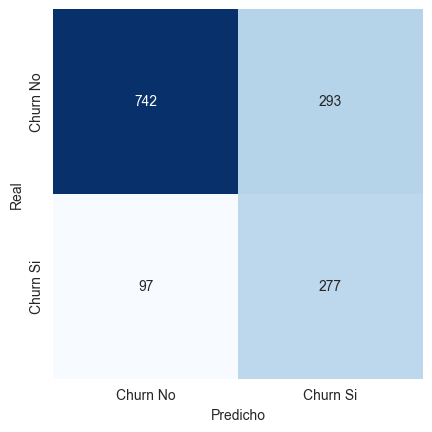

In [25]:
sns.heatmap(
        confusion_matrix(y_test, y_pred_bal),
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        xticklabels=["Churn No", "Churn Si"],
        yticklabels=["Churn No", "Churn Si"]
    )

plt.xlabel("Predicho")
plt.ylabel("Real")

print(classification_report(y_test, y_pred_bal))

## **Parte II: Reformulando el problema**

*La columna que elegimos usar como nuevo target es SeniorCitizen*

*Vamos a intentar predecir si el cliente es un Senior Citizen o no*

In [27]:

X = df.drop("SeniorCitizen", axis=1)
y = df["SeniorCitizen"]

# Training (80%), Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Imputer
imputer = SimpleImputer(strategy="mean")
imputer.fit(X_train)
X_train = imputer.transform(X_train)
X_test = imputer.transform(X_test)

modelo = KNeighborsClassifier(n_neighbors=10)
modelo.fit(X_train, y_train)

# predicción
y_pred = modelo.predict(X_test)

# métricas
accuracy_Test = accuracy_score(y_test, y_pred)
precision_Test = precision_score(y_test, y_pred)
recall_Test = recall_score(y_test, y_pred)
f1s_Test = f1_score(y_test, y_pred)


Accuracy promedio: 0.836763662171753
Precision promedio: 0.3333333333333333
Recall promedio: 0.008771929824561403
F1-score promedio: 0.017094017094017096


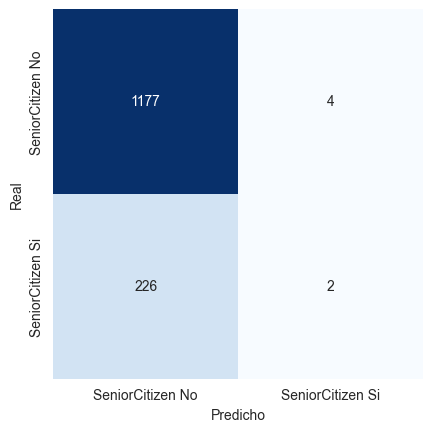

In [28]:
sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        xticklabels=["SeniorCitizen No", "SeniorCitizen Si"],
        yticklabels=["SeniorCitizen No", "SeniorCitizen Si"]
    )

plt.xlabel("Predicho")
plt.ylabel("Real")

print("Accuracy promedio:", accuracy_Test)
print("Precision promedio:", precision_Test)
print("Recall promedio:", recall_Test)
print("F1-score promedio:", f1s_Test)